### Example 6 for the usage of Rela²x.
### See README.md for more information.

- ¹H and ¹³C nuclei.

- Zeeman interaction, J-coupling, and dipole-dipole coupling.

- The Liouvillian superoperator, combining the coherent and incoherent parts.

Import Rela²x.

In [1]:
from rela2x import *

Define the spin system.

In [2]:
spin_system = ['1H', '13C']

Define the coherent and incoherent interactions.

In [3]:
coh_intrs = {'Z': [1, 1],
             'J': [[0, 1],
                   [0, 0]]}

intrs = {'DD': ('2', [[0, 1],
                      [0, 0]], 
                      [2])}

Compute the Liouvillian, combining both parts against a single shared basis, and create a LiouvillianSuperoperator object.

In [4]:
L = liouvillian_superoperator(spin_system, coh_intrs, intrs)

################################################################################
                         Hamiltonian superoperator (H)                          
################################################################################

Computing H for the coherent interactions...
H computed in 0.01 seconds.

Changing basis...
Basis changed in 0.03 seconds.

Final clean-ups...
Done in 0.03 seconds.

################################################################################
                          Relaxation superoperator (R)                          
################################################################################

Computing R for incoherent interaction pairs...
  DD12 * DD12
R computed in 0.08 seconds.

Changing basis...
Basis changed in 0.07 seconds.

Final clean-ups...
Done in 0.22 seconds.



Display $L$ and visualize.

Matrix([
[0,                                                                                                                          0,                                                                                                                           0,                                                             0,                                                                                                                                                0,                                                                                                                                               0,                                                                                                                                                                                                0,                                                                                                                                                                                               

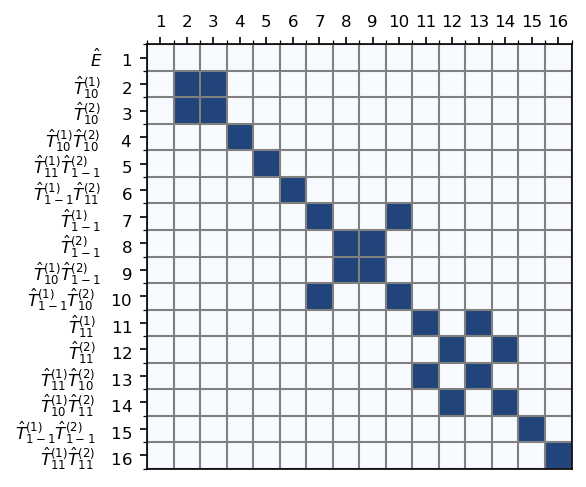

In [5]:
display(L.op)
L.visualize(basis_symbols=L.basis_symbols)

The two parts remain available as `L.H` and `L.R`. A matrix element of the Liouvillian carries both a coherent frequency and a relaxation rate.

In [6]:
print('coherent   (L.H.frequency):', L.H.frequency('111'))
print('incoherent (L.R.rate)     :', L.R.rate('111'))
print()
print('combined   (L.element)    :', L.element('111'))

coherent   (L.H.frequency): \omega_{1H}
incoherent (L.R.rate)     : J^{DD12}_{20}(0)/12 + J^{DD12}_{20}(\omega_{13C})/8 + J^{DD12}_{20}(\omega_{1H})/16 + J^{DD12}_{20}(\omega_{13C} - \omega_{1H})/48 + J^{DD12}_{20}(\omega_{13C} + \omega_{1H})/8

combined   (L.element)    : -I*\omega_{1H} - J^{DD12}_{20}(0)/12 - J^{DD12}_{20}(\omega_{13C})/8 - J^{DD12}_{20}(\omega_{1H})/16 - J^{DD12}_{20}(\omega_{13C} - \omega_{1H})/48 - J^{DD12}_{20}(\omega_{13C} + \omega_{1H})/8


Now repeat for a homonuclear pair. The J-coupling flip-flop term is secular for a homonuclear pair, so it stays in the Liouvillian instead of being dropped.

In [7]:
L_hom = liouvillian_superoperator(['1H', '1H'], coh_intrs, intrs)

################################################################################
                         Hamiltonian superoperator (H)                          
################################################################################

Computing H for the coherent interactions...
H computed in 0.01 seconds.

Changing basis...
Basis changed in 0.03 seconds.

Final clean-ups...
Done in 0.03 seconds.

################################################################################
                          Relaxation superoperator (R)                          
################################################################################

Computing R for incoherent interaction pairs...
  DD12 * DD12
R computed in 0.17 seconds.

Changing basis...
Basis changed in 0.07 seconds.

Final clean-ups...
Done in 0.14 seconds.



Display and visualize, exactly as above. The extra structure from the flip-flop term is visible directly in the nonzero pattern.

Matrix([
[0,                                                                                    0,                                                                                    0,                             0,                                                   0,                                                   0,                                                                                                        0,                                                                                                        0,                                                                                                      0,                                                                                                      0,                                                                                                         0,                                                                                                         0,                                             

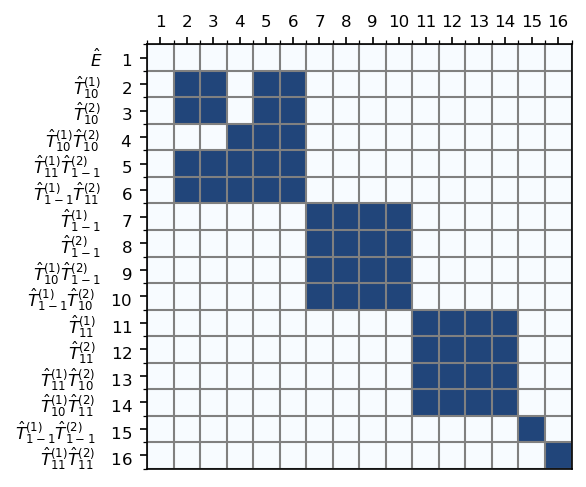

In [8]:
display(L_hom.op)
L_hom.visualize(basis_symbols=L_hom.basis_symbols)

Apply the isotropic rotational diffusion model — the standard model for random molecular tumbling — to the relaxation part; the coherent part is left untouched.

In [9]:
L.to_isotropic_rotational_diffusion(fast_motion_limit=True)

Compute the equations of motion for the observables, picking out a couple of operators to keep the output readable.

In [10]:
eoms = equations_of_motion(L, included_operators=[1, 2])
eoms

Eq(Matrix([
[Derivative(\langle \hat{T}_{10}^{(1)}\rangle(t), t)],
[Derivative(\langle \hat{T}_{10}^{(2)}\rangle(t), t)]]), Matrix([
[-5*\tau_c*G^{DD12}_{20}(0)*\langle \Delta \hat{T}_{10}^{(1)}\rangle(t)/6 - 5*\tau_c*G^{DD12}_{20}(0)*\langle \Delta \hat{T}_{10}^{(2)}\rangle(t)/12],
[-5*\tau_c*G^{DD12}_{20}(0)*\langle \Delta \hat{T}_{10}^{(1)}\rangle(t)/12 - 5*\tau_c*G^{DD12}_{20}(0)*\langle \Delta \hat{T}_{10}^{(2)}\rangle(t)/6]]))